In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml

In [2]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    # chunksize=100000,
    skipbadfiles=True,
)

In [3]:
channels = [
    "data_control_region_1muLj",
]

p = sidm_processor.SidmProcessor(
    channels,
    ["mu_lj_base"],
    unweighted_hist=False,
)

# Test Processing

In [4]:
bkg = [
    'DYJetsToLL_M10to50',
    'DYJetsToLL_M50',
]

In [5]:
fileset = utilities.make_fileset(bkg, "skimmed_llpNanoAOD_v2", max_files=10, location_cfg="backgrounds.yaml")
output_bkg = runner.run(fileset, treename="Events", processor_instance=p)
# coffea.util.save(output_signal, "output_signal"+ channelname+ ".coffea"  )

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

DYJetsToLL_M50 is simulation. Scaling histograms or cutflows according to lumi*xs.
DYJetsToLL_M10to50 is simulation. Scaling histograms or cutflows according to lumi*xs.


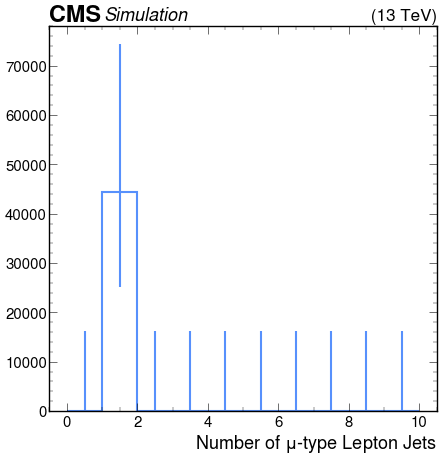

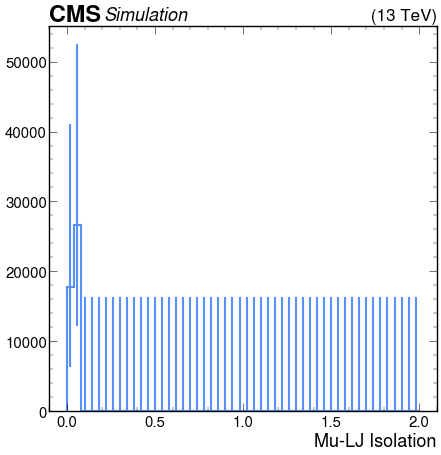

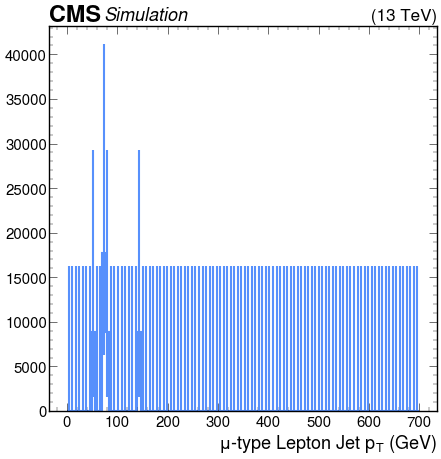

In [8]:
histogram_list  = [ 
"mu_lj_n",
"mu_lj_iso",
"mu_lj_pt",
]

for i, histogram_name in enumerate(histogram_list):
    histogram = output_bkg["out"][bkg[0]]["hists"][histogram_name][channels[0], :]
    utilities.plot(histogram, flow ="none", yerr=True, density=False,  linewidth=3)
    # plt.yscale("log")
    plt.show()
    plt.close()

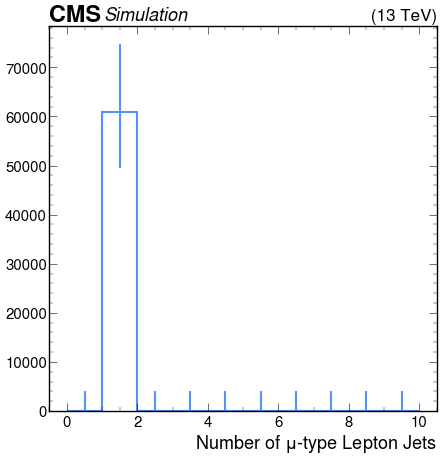

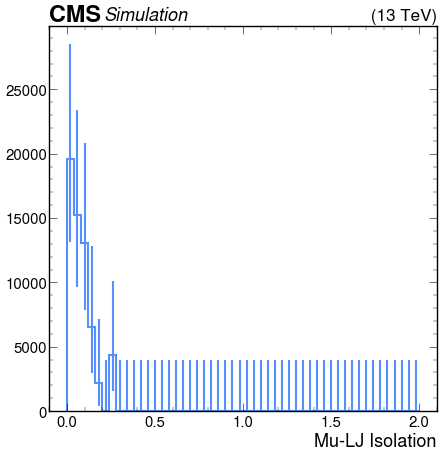

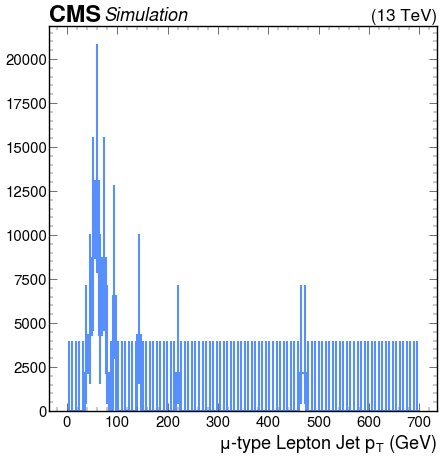

In [9]:
histogram_list  = [ 
"mu_lj_n",
"mu_lj_iso",
"mu_lj_pt",
]

for i, histogram_name in enumerate(histogram_list):
    histogram = output_bkg["out"][bkg[1]]["hists"][histogram_name][channels[0], :]
    utilities.plot(histogram, flow ="none", yerr=True, density=False,  linewidth=3)
    # plt.yscale("log")
    plt.show()
    plt.close()